In [1]:
import numpy as np
from scipy.stats import norm, binom
import datetime
import pandas as pd
import matplotlib.pyplot as plt

### Task 1

In [2]:
mu = np.array([0.02, 0.07, 0.15, 0.2])
sigma = np.array([0.05, 0.12, 0.17, 0.25])
R = np.array([[1, 0.3, 0.3, 0.3],
    [0.3, 1, 0.6, 0.6],
    [0.3, 0.6, 1, 0.6],
    [0.3, 0.6, 0.6, 1]])
S = np.diag(sigma)
cov = S @ R @ S

a) We form the Lagrange function with two Lagrange multipliers $\lambda $ and $\gamma$:
$$L(w, \lambda, \gamma) = \frac{1}{2}w^{T}\Sigma w + \lambda(m − w^{T}\mu) + \gamma(1 − w^{T}\mathbf{1})$$
where using the notations from the lectures the covariance matrix is given by $\Sigma=SRS$, where S represents diagonal matrix formed by individual volatilities and R represents covariance matrix with ones on the main diagonal. 

FOCs are given below:
$$\frac{\delta L}{\delta w} = \Sigma w − \lambda \mu − \gamma \mathbf{1} = 0$$ 
$$\frac{\delta L}{\delta \lambda} = m − w^{T}\mu = 0$$
$$\frac{\delta L}{\delta \gamma} = 1 − w^{T}\mathbf{1} = 0$$


b)
Using the results from CQF Lecture on Portfolio Optimisation we have:
$$A = \mathbf{1}^{T}\Sigma^{-1}\mathbf{1}$$
$$B = {\mu}^{T}\Sigma^{-1}\mathbf{1}$$
$$C = {\mu}^{T}\Sigma^{-1}{\mu}$$
$$D = AC - B^2$$ 
These are used to express the efficient frontier analytically — the minimum variance portfolio and the entire frontier can be written as closed-form functions of A, B, C, D.

c) To find optimal portfolio weights let's use the formulas from lectures:
$$w^{*} = \Sigma^{-1}(\lambda \mu + \gamma \mathbf{1})$$
where lagrange multipliers are given by:
$$\lambda = \frac{Am−B}{D}$$ and $$\gamma = \frac{C−Bm}{D}$$
We can compute optimal portfolio volatility as:
$$\sigma_p = \sqrt{w^{*T}\Sigma w^{*}}$$

In [3]:
ones = np.ones(len(mu))
cov_inv = np.linalg.inv(cov)

A = ones.T @ cov_inv @ ones
B = mu.T @ cov_inv @ ones
C = mu.T @ cov_inv @ mu
D = A * C - B**2
m = 0.045
lam = (A*m - B)/D
gam = (C - B*m)/D
w = cov_inv @ (lam * mu + gam * ones)
vol = np.sqrt(w.T @ cov @ w) * 100
print(f"optimal portfolio weights: {w}")
print(f"optimal portfolio volatility: {vol}")

optimal portfolio weights: [0.78511066 0.05386419 0.13355472 0.02747042]
optimal portfolio volatility: 5.840090674110409


d) From the optimal weight formula we have
$w^{*} = \Sigma^{-1}(\lambda \mu + \gamma \mathbf{1})$. That is, optimal weight for an asset i is asset's own signal (in numerator) weighted/scaled by its own signal precision (diagonal element in position ixi in denominator) and sum of other assets' signals weighted by partial correlations with other assets (value in row i in denominator). Mathematically it can expressed as in below:

$$w_{i}^{*}\propto c_{ii}v_{i}+\sum_{i}^{j}c_{ij}v_{j}$$
where $c_{ij}$ stands for element (i,j) in inverse covariance matrix and $v_{i} = \lambda \mu_{i} + \gamma$.

From this formula it's clear that weight of asset 1 is relatively high for two reasons.

First, the return target is only 4.5%, which is low relative to the available asset returns, so the Lagrange multiplier $\lambda$ penalising the return constraint is small (0.036). This means differences in $\mu_i$ contribute little to the signal $v_i = \lambda\mu_i + \gamma$, and the common term $\gamma$ dominates across all assets. Asset returns therefore play a minor role in determining optimal weights.

Second, asset 1 has the lowest volatility and it can be seen from the inverse covariance matrix that its precision is 4 times bigger than of its closest competitor, which is related to the fact that variance is volatility in power of 2. Note that partial correlations $c_{1j}$, although negatively impacting asset 1 weight, are significantly lower than asset 1 precision in magnitude.  

In [4]:
print(f"inverse covariance matrix: \n\n {cov_inv}")

inverse covariance matrix: 

 [[455.95854922 -25.90673575 -18.28710759 -12.43523316]
 [-25.90673575 127.73459988 -32.38341969 -22.02072539]
 [-18.28710759 -32.38341969  63.64630582 -15.54404145]
 [-12.43523316 -22.02072539 -15.54404145  29.43005181]]


### Task 2

a) Let's rewrite the formulas for sensitivities and compute VaR and ES sensitivity with respect to weight of the first asset:
$$\frac{\delta VaR(w)}{\delta w_{i}} = \mu_{i} + z_{\alpha} \frac{(\Sigma w)_{i}}{\sqrt{w^{T}\Sigma w}}$$
$$\frac{\delta ES(w)}{\delta w_{i}} = \mu_{i} - \frac{ \phi(z_{\alpha})}{1-c} \frac{(\Sigma w)_{i}}{\sqrt{w^{T}\Sigma w}}$$

In [5]:
mu = np.array([0,0,0])
vol = np.array([0.3, 0.2, 0.15])
w = np.array([0.5, 0.2, 0.3])
R = np.array([[1,0.8,0.5],[0.8, 1, 0.3],[0.5,0.3,1]])
S = np.diag(vol)
cov = S @ R @ S
c = 0.99
z_score = norm.ppf(1-c)
asset_ind = 0
weighted_cov = cov @ w
portfolio_vol = w.T @ cov @ w
var_s = mu[asset_ind] + z_score * weighted_cov[asset_ind] * portfolio_vol**(-0.5)
es_s = mu[asset_ind] - norm.pdf(z_score, loc=0, scale=1) / (1 - c) * weighted_cov[asset_ind] * portfolio_vol**(-0.5)
print(f"VaR sensitivity to asset 1 weight: {var_s}")
print(f"ES sensitivity to asset 1 weight: {es_s}")

VaR sensitivity to asset 1 weight: -0.6838647463691414
ES sensitivity to asset 1 weight: -0.7834795763585853


b) Both VaR and ES sensitivity depend on the sensitivity of portfolio volatility to portfolio weights, i.e. $\frac{(\Sigma w)_{i}}{\sqrt{w^{T}\Sigma w}}$. In turn, the numerator of this ratio depends on the sum of covariances weighted by asset weights in row i, i.e. $(\Sigma w)_{i} = w_{i}*\sigma_{i}^2 + \sum_{j}w_{j}cov_{ij}$ which represents the sensitivity of portfolio variance with respect to weight of asset i. In our particular example, all covariances are positive, weights are positive too, so the numerator will be positive. Given z-score is negative, expected return is 0, sensitivities will be negative.

Negative VaR sensitivities to asset weights for portfolio management mean that keeping all other asset weights $w_{j}$ fixed increasing asset weight $w_{i}$ will locally increase the worst case loss. As discussed, this is the result of positive co-movements of asset returns. However, in reality we cannot keep all other asset weights fixed because all weights must add up to 1, so in reality marginal increase of one asset weight will be at least partially offset by decrease of another asset weight.         

c) Given all asset returns $\mu_{i}$, z-score and denominator $\sqrt{w^{T}\Sigma w}$ equal among each other, the sensitivities differ due to the numerator $(\Sigma w)_{i} = w_{i}*\sigma_{i}^2 + \sum_{j}w_{j}cov_{ij}$. Based on the inputs, asset 1 has the greatest weight (0.5), the highest volatility (0.30), and the highest cross-asset correlations, all of which contribute to the largest value of $(\Sigma w)_{1}$ and therefore the highest VaR sensitivity among the three assets.

d) Recall the relationship between ES and VaR:
$$ES_{c}(X) = \mathbb{E}[X|X\le VaR_{c}(X)] = \frac{1}{1-c}\int_{0}^{1-c}VaR_{u}(X)du = \newline = \frac{1}{1-c}\int_{c}^{1}VaR_{u}(X)du = \frac{1}{1-c}\int_{c}^{1}(\mu +\sigma\Phi^{-1}(1-u))du = \newline = \mu + \sigma\frac{\int_{c}^{1}\Phi^{-1}(1-u)du}{1-c}$$
The comparison between absolute ES and VaR sensitivities with respect to asset weights boils down to comparison between constants $|\frac{\int_{c}^{1}\Phi^{-1}(1-u)du}{1-c}|$ and $|\Phi^{-1}(1-c)|$. Given $|\Phi^{-1}(1-u)| > |\Phi^{-1}(1-c)|$ for $u \in (c,1)$ and $1-c < 1$ we have $|\frac{\int_{c}^{1}\Phi^{-1}(1-u)du}{1-c}| > |\Phi^{-1}(1-c)|$. Since this term is a constant value which is satisfied for all probability distributions, absolute ES sensitivity will be greater than VaR sensitivity.

### Task 3

In [6]:
# load data set
data_full = pd.read_excel("Indices_Download_2026.xlsx", index_col='Date')

# 'Date' parsed as datetime, if not automatic
data_full.index = pd.to_datetime(data_full.index)

# Filtering range of dates
data = data_full.loc["2025-01-01": "2026-01-15"].copy()

# define static parameters
cl = 0.99
inverse_cdf = norm.ppf(1-cl)
lookback_period = 21
window = 10
ticker = '^GSPC'
print(f'Exact value of Normal CDF for p = {1-cl:.2f} is: \033[1m{inverse_cdf}\033[0m')

# define utilities for volatility and VaR calculation, VaR analytics and plotting

def ewma_vol(r, decay, index = None, vol = None) -> list:
    """
    Calculate Exponentially Weighted Moving Average (EWMA) volatility recursively.

    Parameters:
    r (array-like): Array of returns.
    decay (float): Decay factor for EWMA.
    index (int, optional): Current index in the recursion. Defaults to None.
    vol (float, optional): Current volatility value. Defaults to None.

    Returns:
    list: List of volatility values.
    """

    if index is None:
        index = 0
        vol = np.mean(r**2)
    if index == len(r):
        return []

    new_vol = decay * vol + (1 - decay) * r[index]**2
    return [new_vol**0.5] + ewma_vol(r, decay, index+1, new_vol) 

def vol_calculator(data, method, lookback_period=None, decay=None) -> pd.Series:
    """
    Calculate volatility using specified method.

    Parameters:
    data (DataFrame): DataFrame containing 'daily_r' column.
    method (str): Method to use ('rw' for rolling window, 'ewma' for EWMA).
    lookback_period (int, optional): Lookback period for rolling window.
    decay (float, optional): Decay factor for EWMA.

    Returns:
    Series: Series of volatility values.
    """
    if method == "rw":
        print(f"calculating rolling window volatility with lookback period: {lookback_period}")
        return data['daily_r'].rolling(lookback_period, min_periods=lookback_period).std()
    elif method == "ewma":
        print(f"calculating EWMA volatility with decay parameter: {decay}")
        r = data['daily_r'].to_numpy()
               
        result = ewma_vol(r[1:], decay)
        return pd.Series([np.nan] + result, index=data.index)
        
def var_analytics(data, lookback_period, var_window, vol_type, decay=None) -> tuple[float, int]:
    """
    Perform Value at Risk (VaR) analytics on the data.

    Parameters:
    data (DataFrame): DataFrame containing price data with ticker column.
    lookback_period (int): Lookback period for volatility calculation.
    var_window (int): Window for VaR calculation (e.g., 10 for 10-day VaR).
    vol_type (str): Type of volatility ('rw' or 'ewma').
    decay (float, optional): Decay factor if using EWMA.

    Returns:
    tuple[float, int]: (exception_rate as percentage, total_observations)
    """
    
    # Calculate mean and standard deviation of returns
    data['daily_r'] = np.log(data[ticker]) - np.log(data[ticker].shift(1))
    data['r'] = np.log(data[ticker].shift(-var_window)) - np.log(data[ticker])
    
    data['daily_vol'] = vol_calculator(data, vol_type, lookback_period, decay)
    data['vol']  = data['daily_vol'] * np.sqrt(var_window)
    data['VaR'] = inverse_cdf * data['vol']

    # Count the number of times the actual return exceeded the VaR estimate
    data['exception'] = data['r'] < data['VaR']
    clean = data.dropna(subset=['r', 'VaR', 'exception'])
    exceptions = clean['exception'].sum()
    total_observations = len(clean)

    # Calculate the proportion of exceptions
    exception_rate = exceptions / total_observations * 100
    print(f'Number of exceptions: {exceptions}')
    print(f'Total observations: {total_observations}')
    print(f'Exception rate: {exception_rate:.4f} in %')
    
    return exception_rate, total_observations
    
def plot_var(data) -> None:
    """
    Plot the backtesting of Analytical VaR.

    Parameters:
    data (DataFrame): DataFrame with VaR and return data.

    Returns:
    None: Displays the plot.
    """

    exceptions = data.loc[data['exception']]
    plt.title('Backtesting of Analytical VaR');
    fig_size = plt.rcParams["figure.figsize"]
    fig_size[0] = 20
    fig_size[1] = 5
    plt.rcParams["figure.figsize"] = fig_size

    varPlt, = plt.plot(data.index, data['VaR'], color='RED');
    r10dplt, = plt.plot(data.index, data['r']);

    varBreachPlt = plt.scatter(exceptions.index, exceptions['VaR'], color='BLACK', marker='x');

    plt.legend(["VaR 99%/10D","return_10D fwd","Breach"]);
    plt.grid();

    fig = plt.figure();
    ax1 = fig.add_subplot(211);
    ax1.set_title('Index Level');
    ax1.plot(data.index, data[ticker])
    ax1.legend(["Index Level"]);
    ax1.grid();
    plt.show();

Exact value of Normal CDF for p = 0.01 is: -2.3263478740408408


a) Report the count and percentage of VaR breaches. We'll start with loading the data and saving key parameters.

In [7]:
exception_rate, T = var_analytics(data, lookback_period = 21, var_window=10, vol_type = "rw")

calculating rolling window volatility with lookback period: 21
Number of exceptions: 10
Total observations: 229
Exception rate: 4.3668 in %


b) Let's present a plot which identifies the breaches visually

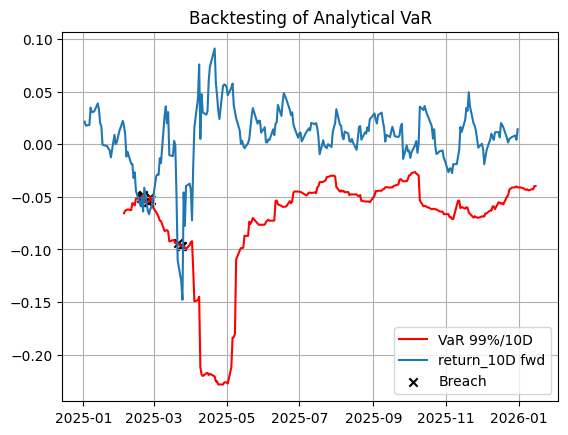

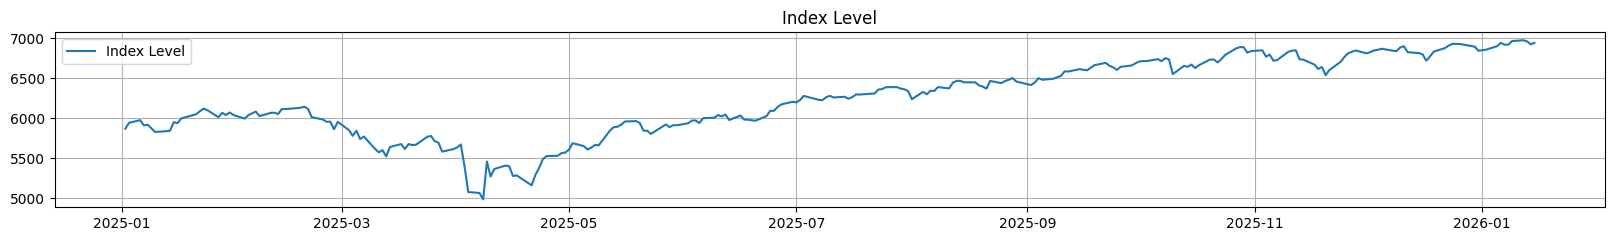

In [8]:
plot_var(data)

c) Let's report traffic-light ranges for breaches (green / yellow / red). The number of exceptions satisfies $B \propto Binomial(T, 0.01)$. Assume $B = b$ exceptions realized in our data.

Risk traffic-light zones are computed by binomial percentiles and depend on the number of eligible
comparisons T, on which VaR is compared to the 10-D return. 

Green zone is the most restrictive range of breaches $0 < b \le q_{G}$, probability $p_{G} = 0.95$. Yellow zone
is $q_{G} < b \le q_{Y}$ , red zone if breaches are too many $b > q_{Y}$ . Let's Take $p_{Y} = 0.9999$.

In [9]:
q_g, q_y = binom.ppf(0.95, T, 0.01), binom.ppf(0.9999, T, 0.01)
print(f"Green zone: b<{q_g} \nYellow zone: {q_g}<b<={q_y} \nRed zone b>{q_y}")


Green zone: b<5.0 
Yellow zone: 5.0<b<=10.0 
Red zone b>10.0


### Task 4

a) Let's report the count and percentage of VaR breaches for EWMA method displayed below:
$$\sigma_{t+1|t}^{2} = \lambda \sigma_{t|t-1}^{2} + (1-\lambda)r_{t}^2$$

In [10]:
exception_rate, T = var_analytics(data, lookback_period = 21, var_window=10, vol_type = "ewma", decay = 0.72)

calculating EWMA volatility with decay parameter: 0.72
Number of exceptions: 11
Total observations: 249
Exception rate: 4.4177 in %


b) Similar to task 3, let's present a plot which identifies the breaches visually

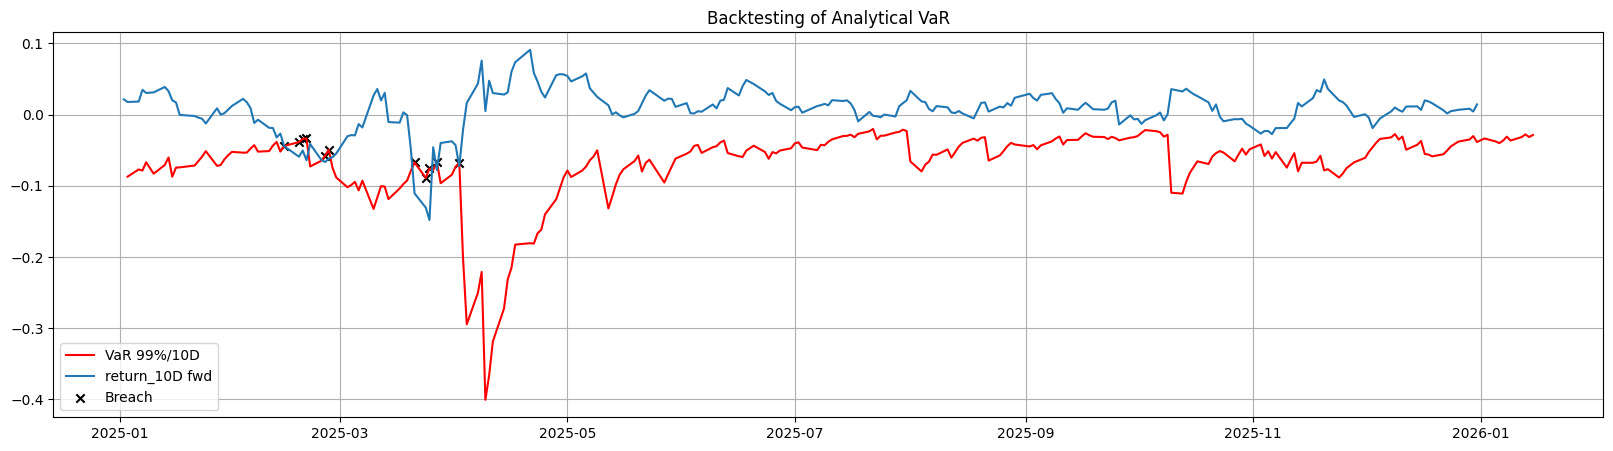

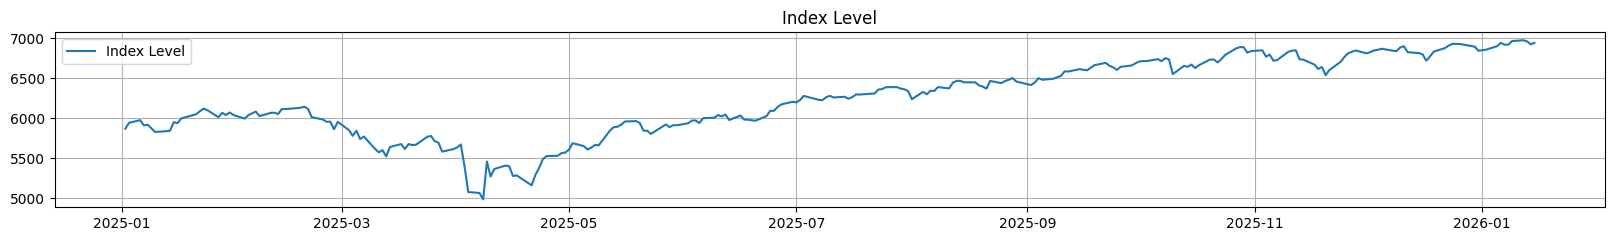

In [11]:
plot_var(data)

c) The three methods differ fundamentally in how they use past data to estimate volatility and construct VaR.

Historical simulation VaR assigns equal weight to every observation within the lookback window and makes no distributional assumption — the VaR estimate is simply the empirical quantile of the observed return distribution. Its main limitation is a characteristic plateau effect: the VaR estimate stays flat until an extreme observation enters or leaves the window, at which point it jumps discretely. The longer the window, the smoother but less responsive the estimate.

The rolling-window parametric approach also assigns equal weight of 1/N to each squared return within the window, but imposes a normal distribution assumption. With N = 21, the latest return receives only approximately 5% weight, so the estimate reacts sluggishly to new information and shares the same step-function-like behaviour when extreme observations roll out of the window.

The EWMA approach addresses these limitations by assigning exponentially declining weights to past observations, so that the most recent data points carry the greatest influence and the importance of each prior observation decays at a predetermined rate. With a decay parameter of 0.72, the most recent return receives a weight of 28%, the preceding one roughly 20%, then 15%, and so on — reaching near-zero weight well within a 21-day horizon. This makes EWMA substantially more responsive to volatility clustering and regime shifts than either the historical simulation or rolling-window parametric approach.